In [9]:
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd
import matplotlib.pyplot as plt

***In this task, we analyzed 500,000 quark and gluon jets from the Pythia 8 dataset using vectorized NumPy operations for efficient coordinate transformations and observable calculations. We implemented a Lorentz boost to the Jet center-of-mass frame, verified by ensuring $\sum \vec{p} \approx 0$.***
***Our findings show that while Multiplicity and Invariant Mass are frame-invariant, working in the rest frame removes longitudinal stretching, allowing for a more isotropic view of the jet's internal geometry. Using a Random Forest classifier, we achieved an optimal AUC of 86.51 with max_depth=10, identifying Multiplicity as the most discriminating physical feature when the model is properly regularized against overfitting.***

**(a) Data loading & exploration**

In [10]:


file_paths = [
    r'C:\Users\Yash Jha\OneDrive\Desktop\sem4\QG_jets.npz',
    r'C:\Users\Yash Jha\OneDrive\Desktop\sem4\QG_jets_1.npz',
    r'C:\Users\Yash Jha\OneDrive\Desktop\sem4\QG_jets_2.npz',
    r'C:\Users\Yash Jha\OneDrive\Desktop\sem4\QG_jets_3.npz',
    r'C:\Users\Yash Jha\OneDrive\Desktop\sem4\QG_jets_4.npz',
]

loaded = [np.load(f) for f in file_paths]

def pad_to_match(arrays, axis=1):
    """Pad arrays along `axis` to the maximum size found across all arrays."""
    max_size = max(a.shape[axis] for a in arrays)
    padded = []
    for a in arrays:
        pad_width = [(0, 0)] * a.ndim
        pad_width[axis] = (0, max_size - a.shape[axis])
        padded.append(np.pad(a, pad_width, mode='constant', constant_values=0))
    return padded

data = {}
for key in loaded[0].keys():
    arrays = [f[key] for f in loaded]
    
    # Only pad if shapes differ, otherwise concatenate directly
    if len(set(a.shape[1:] for a in arrays)) > 1:
        arrays = pad_to_match(arrays, axis=1)
    
    data[key] = np.concatenate(arrays, axis=0)

print({k: v.shape for k, v in data.items()})  # verify final shapes

{'X': (500000, 139, 4), 'y': (500000,)}


In [11]:
x=data['X']
labels=data['y']


In [12]:
print(x.shape)

(500000, 139, 4)


In [13]:
print(labels)

[1. 1. 1. ... 1. 0. 1.]


In [14]:
print(np.shape(labels[labels==1]))

(250000,)


In [15]:
multiplicity=np.sum(x[:, :, 0]>0, axis=1)
quarks=multiplicity[labels==1]
gluons=multiplicity[labels==0]

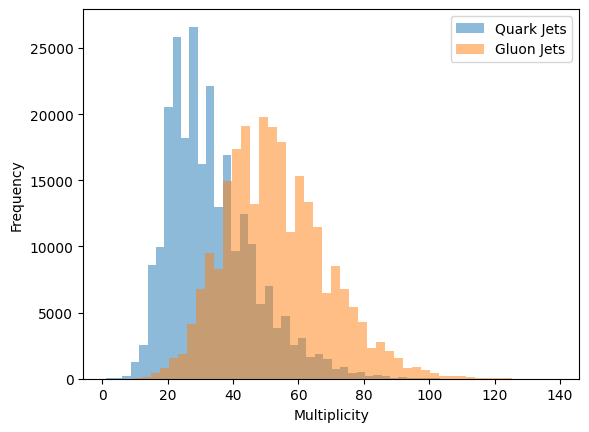

In [17]:
plt.hist(quarks, bins=50, alpha=0.5, label='Quark Jets')
plt.hist(gluons, bins=50, alpha=0.5, label='Gluon Jets')
plt.xlabel('Multiplicity')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [18]:
pt1=x[:, :, 0]
leading_id=np.argmax(pt1, axis=1)
leading_particle=x[np.arange(len(x)), leading_id]
leading_pt=leading_particle[:, 0]
leading_eta=leading_particle[:, 1]

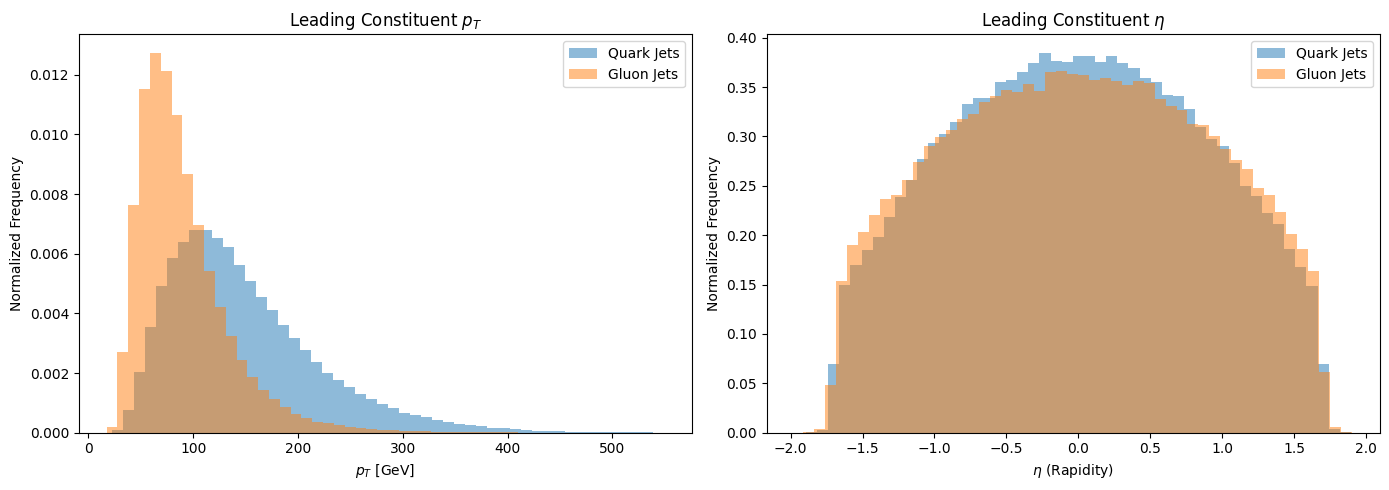

In [19]:
quark_leading_pt = leading_pt[labels==1]
gluon_leading_pt = leading_pt[labels==0]

quark_leading_eta = leading_eta[labels == 1]
gluon_leading_eta = leading_eta[labels == 0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(quark_leading_pt, bins=50, alpha=0.5, label='Quark Jets', density=True)
ax1.hist(gluon_leading_pt, bins=50, alpha=0.5, label='Gluon Jets', density=True)
ax1.set_title('Leading Constituent $p_T$')
ax1.set_xlabel('$p_T$ [GeV]')
ax1.set_ylabel('Normalized Frequency')
ax1.legend()

ax2.hist(quark_leading_eta, bins=50, alpha=0.5, label='Quark Jets', density=True)
ax2.hist(gluon_leading_eta, bins=50, alpha=0.5, label='Gluon Jets', density=True)
ax2.set_title('Leading Constituent $\eta$')
ax2.set_xlabel('$\eta$ (Rapidity)')
ax2.set_ylabel('Normalized Frequency')
ax2.legend()

plt.tight_layout()
plt.show()

**(b) Jet Observables**

In [20]:
pt=x[:, :, 0]
y=x[:, :, 1]
phi=x[:, :, 2]


px=pt*np.cos(phi)
py=pt*np.sin(phi)
pz=pt*np.sinh(y)
energy=pt*np.cosh(y)


In [21]:
p4=np.stack((energy, px, py, pz), axis=-1)

In [22]:
jet_p4=np.sum(p4, axis=1)
jet_E=jet_p4[:, 0]
jet_px=jet_p4[:, 1]
jet_py=jet_p4[:, 2]
jet_pz=jet_p4[:, 3]
m2= jet_E**2 - jet_px**2 - jet_py**2 - jet_pz**2
jet_mass=np.sqrt(np.maximum(m2, 0))

In [23]:
phi_j=np.arctan2(jet_py, jet_px)
eta_j=np.arctanh(jet_pz/jet_E)

eta_j_ext= eta_j[:, np.newaxis]
phi_j_ext= phi_j[:, np.newaxis]

d_eta=x[:, :, 1] - eta_j_ext
d_phi=x[:, :, 2] - phi_j_ext

d_phi = (d_phi + np.pi) % (2 * np.pi) - np.pi
delta_r=np.sqrt((d_eta)**2 + (d_phi)**2)

In [24]:
pt_particles=x[:, :, 0]
mask=pt_particles>0
num_w = np.sum(pt_particles * delta_r * mask, axis=1)
den_w = np.sum(pt_particles * mask, axis=1)
jet_width = np.divide(num_w, den_w, out=np.zeros_like(num_w), where=den_w!=0)

sum_pt_sq = np.sum((pt_particles**2) * mask, axis=1)
pt_dispersion = np.sqrt(sum_pt_sq) / den_w

**(c) Boost to Jet: COM frame**

*we define the boost vector, or $\vec{\beta}$ as  $\vec{\beta} = \vec{p}_J / E_J$.*

*we define the lorentz factor, or $\gamma$ as :*
*$\gamma = E_J / m_J $*


*we get E' by projecting E along beta vector using the formula  $E' = \gamma(E - \vec{\beta} \cdot \vec{p})$.*

*finally, we get the momentum in rest phase, p', as $$\vec{p}' = \vec{p} + \frac{\gamma - 1}{\beta^2}(\vec{\beta} \cdot \vec{p})\vec{\beta} - \gamma E \vec{\beta}$$*

In [25]:
def boost_to_rest_frame(p4_constituents, total_jet_p4):

    E_J, px_J, py_J, pz_J = total_jet_p4
    mag_p = np.sqrt(px_J**2 + py_J**2 + pz_J**2)
    
    
    beta = np.array([px_J, py_J, pz_J]) / E_J
    beta_mag = np.linalg.norm(beta)
    gamma = E_J / np.sqrt(E_J**2 - mag_p**2) 
    
    
    E = p4_constituents[:, 0]
    p = p4_constituents[:, 1:4] 
    
   
    beta_dot_p = np.dot(p, beta)
    
 
    E_prime = gamma * (E - beta_dot_p)
    
    if beta_mag > 0:
        p_prime = p + ((gamma - 1) / (beta_mag**2 + 1e-8) * beta_dot_p[:, np.newaxis]) * beta - (gamma * E[:, np.newaxis]) * beta
    else:
        p_prime = p
        
    return np.column_stack([E_prime, p_prime])

# Verification
example_boosted = boost_to_rest_frame(p4[0], jet_p4[0])
mask0 = x[0, :, 0] > 0
sum_p_prime = np.sum(example_boosted[mask0, 1:4], axis=0)
print(f"Rest Frame Total P check (should be ~0): {sum_p_prime}")

Rest Frame Total P check (should be ~0): [-5.73021890e-06  1.50842882e-04  4.53473947e-06]


*the boosted P is verified by checking it for the first jet, which gives us all three momenta as very close to zero, hence we can see that we have successfully boosted it into it's rest phase*





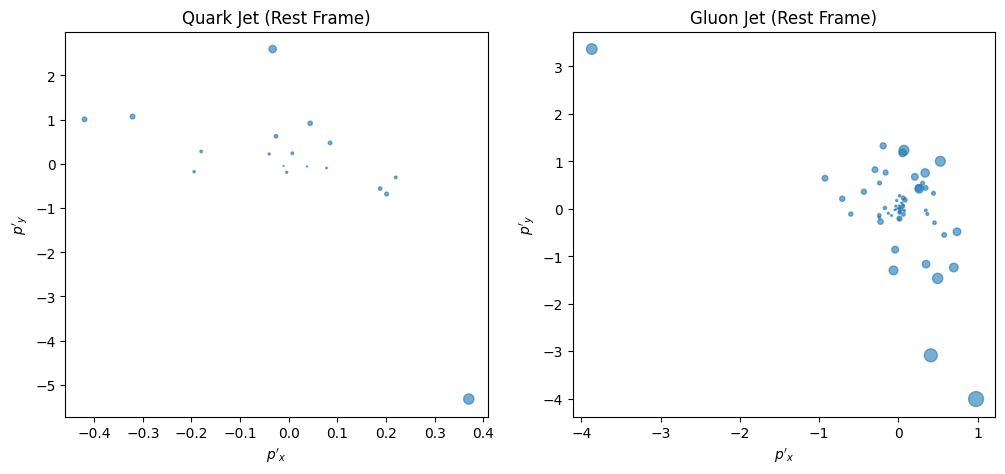

In [26]:
def plot_rest_frame(jet_idx, title):
    mask_j = x[jet_idx, :, 0] > 0
    
    boosted = boost_to_rest_frame(p4[jet_idx], jet_p4[jet_idx])
    
    clean = boosted[mask_j]
    
    plt.scatter(clean[:, 1], clean[:, 2], s=clean[:, 0]*10, alpha=0.6)
    plt.xlabel("$p'_x$")
    plt.ylabel("$p'_y$")
    plt.title(title)

# Plotting one of each
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plot_rest_frame(np.where(labels==1)[0][0], "Quark Jet (Rest Frame)")
plt.subplot(1, 2, 2)
plot_rest_frame(np.where(labels==0)[0][0], "Gluon Jet (Rest Frame)")
plt.show()

**(d)Quark vs Gluon Classification using RandomForest Decision trees**

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier 
from sklearn.metrics import roc_curve, auc, confusion_matrix

features = pd.DataFrame({
    'mass': jet_mass,
    'width': jet_width,
    'dispersion': pt_dispersion,
    'multiplicity': multiplicity 
})

X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)


clf = RandomForestClassifier(n_estimators =500, max_depth=10, n_jobs=-1)
clf.fit(X_train, y_train)


y_score = clf.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)


importances = clf.feature_importances_
best_feat = features.columns[np.argmax(importances)]
print(f"The most discriminating feature is: {best_feat}")

The most discriminating feature is: multiplicity


Model AUC Score: 0.8650

Classification Report:
              precision    recall  f1-score   support

       Gluon       0.77      0.81      0.79     49673
       Quark       0.80      0.76      0.78     50327

    accuracy                           0.79    100000
   macro avg       0.79      0.79      0.79    100000
weighted avg       0.79      0.79      0.79    100000



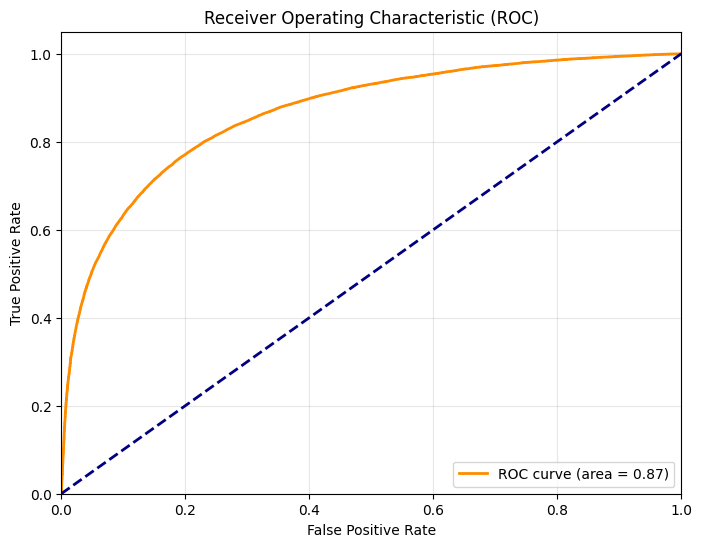

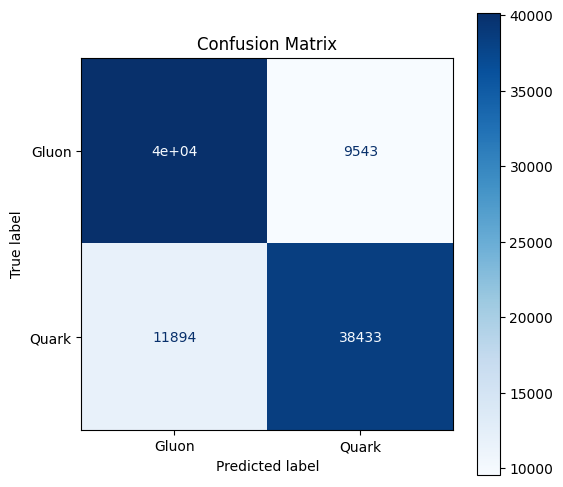

In [28]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


y_pred = clf.predict(X_test)
print(f"Model AUC Score: {roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Gluon', 'Quark']))


plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()


fig, ax = plt.subplots(figsize=(6, 6))
ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test, 
                                      display_labels=['Gluon', 'Quark'], 
                                      cmap=plt.cm.Blues, ax=ax)
plt.title('Confusion Matrix')
plt.show()

In [29]:
rest_frame_widths = np.zeros(len(x))

for i in range(len(x)):
    mask_i = x[i, :, 0] > 0 
    if mask_i.sum() == 0:
        continue
    E_J = jet_p4[i, 0]
    mag_p = np.sqrt(np.sum(jet_p4[i, 1:]**2))

    mass_sq = E_J**2 - mag_p**2
    if mass_sq <= 0 or E_J <= 0:
        continue  

    p4_rest = boost_to_rest_frame(p4[i], jet_p4[i])

    px_prime = p4_rest[:, 1]
    py_prime = p4_rest[:, 2]
    pz_prime = p4_rest[:, 3]

    pt_prime  = np.sqrt(px_prime**2 + py_prime**2)
    r_prime   = np.sqrt(px_prime**2 + py_prime**2 + pz_prime**2)

   
    valid = r_prime > 0
    dist_prime = np.zeros_like(r_prime)
    dist_prime[valid] = pt_prime[valid] / r_prime[valid]


    combined_mask = mask_i & valid

    num = np.sum(pt_prime[combined_mask] * dist_prime[combined_mask])
    den = np.sum(pt_prime[combined_mask])

    rest_frame_widths[i] = num / den if den > 0 else 0



In [30]:
# Classifer using Rest Frame Width along with Lab Frame features
features['rest_width'] = rest_frame_widths
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(features, labels, test_size=0.2, random_state=42)

clf_rest = RandomForestClassifier(n_estimators=500, max_depth=10, n_jobs=-1)
clf_rest.fit(X_train_r, y_train_r)

y_score_r = clf_rest.predict_proba(X_test_r)[:, 1]
fpr_r, tpr_r, _ = roc_curve(y_test_r, y_score_r)
new_auc = auc(fpr_r, tpr_r)

print(f"Original Lab-only AUC: {roc_auc:.4f}")
print(f"New Rest-Frame Augmented AUC: {new_auc:.4f}")

Original Lab-only AUC: 0.8650
New Rest-Frame Augmented AUC: 0.8652


In [31]:
importances = clf_rest.feature_importances_
best_feat = features.columns[np.argmax(importances)]
print(f"The most discriminating feature is: {best_feat}")

The most discriminating feature is: multiplicity


*we can see that AUC increases when the rest-frame feature(rest frame width) is added*

**Some observations from hyperparameter tuning**

*It was observed that, at larger values of **max_depth(100-5000)**, the model overfitted and AUC hovered around **82-84***
*, increasing with increase in n_estimators. This was also accompanied by the most discriminating feature being **Dispersion***


*However, on further hyperparameter tuning, it was observed that at **max_depth=10**, AUC actually increased to around*
*: **86.50 & 86.51** for n_estimators=500 for lab_frame and rest_frame models respectively, with the most discriminating* *feature being **Multiplicity***


*Therefore, we can take **Multiplicity** to be the most discriminating feature in differentiating between Quarks and Gluons*